In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import hanoi

Read data

In [2]:
d = pd.read_csv("data/L1_n1/L1_n1_sigmoid.txt", delimiter=" ")

In [3]:
d.head()

,b,m0,m1,v0,v1,n_gen,allele_fixed
0,0.25,0.0,0.0,0.01,0.01,734,0.0
1,0.25,0.0,0.0,0.01,0.01,94,0.0
2,0.25,0.0,0.0,0.01,0.01,309,0.0
3,0.25,0.0,0.0,0.01,0.01,125,0.0
4,0.25,0.0,0.0,0.01,0.01,116,1.0


In [4]:
d_gb = d.groupby(["b", "m0", "m1", "v0", "v1"])

Extinction prob.

In [5]:
d_gb.agg(p_ext = ("allele_fixed", lambda x: x.isna().sum()/x.size),
         p_fix_1 = ("allele_fixed", "mean")
        ).reset_index()

,b,m0,m1,v0,v1,p_ext,p_fix_1
0,0.25,0.0,0.0,0.01,0.010000,0.0,0.47
1,0.25,0.0,0.0,0.01,0.015849,0.0,0.56
2,0.25,0.0,0.0,0.01,0.025119,0.0,0.47
3,0.25,0.0,0.0,0.01,0.039811,0.0,0.55
4,0.25,0.0,0.0,0.01,0.063096,0.0,0.57
...,...,...,...,...,...,...,...
31995,32.00,2.0,2.0,10.00,1.584893,0.0,1.00
31996,32.00,2.0,2.0,10.00,2.511886,0.0,1.00
31997,32.00,2.0,2.0,10.00,3.981072,0.0,0.99
31998,32.00,2.0,2.0,10.00,6.309573,0.0,0.97


In [6]:
d_1 = d[d["allele_fixed"] == 1].groupby(["b", "m0", "m1", "v0", "v1"])

In [7]:
d_1.agg(t_fix_1 = ("n_gen", "mean")).reset_index()

,b,m0,m1,v0,v1,t_fix_1
0,0.25,0.0,0.0,0.01,0.010000,303.404255
1,0.25,0.0,0.0,0.01,0.015849,269.785714
2,0.25,0.0,0.0,0.01,0.025119,245.297872
3,0.25,0.0,0.0,0.01,0.039811,258.018182
4,0.25,0.0,0.0,0.01,0.063096,261.263158
...,...,...,...,...,...,...
20011,32.00,2.0,2.0,10.00,1.584893,26.990000
20012,32.00,2.0,2.0,10.00,2.511886,36.030000
20013,32.00,2.0,2.0,10.00,3.981072,59.989899
20014,32.00,2.0,2.0,10.00,6.309573,107.092784


In [8]:
d_smr = pd.merge(d_gb.agg(
    p_ext = ("allele_fixed", lambda x: x.isna().sum()/x.size),
    p_fix_1 = ("allele_fixed", "mean")).reset_index(),
                 d_1.agg(t_fix_1 = ("n_gen", "mean")).reset_index(),
                 on = ["b", "m0", "m1", "v0", "v1"],
                 how = "left"
                )

In [9]:
d_smr.head()

,b,m0,m1,v0,v1,p_ext,p_fix_1,t_fix_1
0,0.25,0.0,0.0,0.01,0.010000,0.0,0.47,303.404255
1,0.25,0.0,0.0,0.01,0.015849,0.0,0.56,269.785714
2,0.25,0.0,0.0,0.01,0.025119,0.0,0.47,245.297872
3,0.25,0.0,0.0,0.01,0.039811,0.0,0.55,258.018182
4,0.25,0.0,0.0,0.01,0.063096,0.0,0.57,261.263158


In [10]:
d_smr.shape

(32000, 8)

In [11]:
d_smr["log_v0"] = np.log10(d_smr["v0"])
d_smr["log_v1"] = np.log10(d_smr["v1"])

In [12]:
v0_all = np.sort(d_smr["v0"].unique())
v1_all = np.sort(d_smr["v1"].unique())
def heatmap_panel(data, **kwargs):
    table = data.pivot_table(index="v1", columns="v0", values="p_fix_1")
    sns.heatmap(table, cmap="viridis", cbar=True, **kwargs)

In [13]:
row_order_m = sorted(d_smr["m1"].unique(), reverse=True)  # top row = largest m1
col_order_m = sorted(d_smr["m0"].unique())

In [14]:
def heatmap_panel(data, **kwargs):
    # pivot inside the panel
    table = data.pivot(index="v1", columns="v0", values="p_fix_1")
    sns.heatmap(table, cmap="coolwarm", vmin=0, vmax=1, cbar=False, ax=plt.gca())
    ax = plt.gca()
    ax.invert_yaxis()

    # Get current tick positions
    xticks = ax.get_xticks()
    yticks = ax.get_yticks()

    # Set labels only for every 5th tick
    ax.set_xticklabels([f"$10^{{{int(np.log10(table.columns[int(t)]) )}}}$" if i % 5 == 0 else ""
                        for i, t in enumerate(xticks)], rotation=0)
    ax.set_yticklabels([f"$10^{{{int(np.log10(table.index[int(t)]))}}}$" if i % 5 == 0 else ""
                        for i, t in enumerate(yticks)])
    # Hide axis labels inside panel
    ax.set_xlabel('')
    ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(True)

In [15]:
z_1D = np.linspace(-5, 5, 101).reshape([101,1])

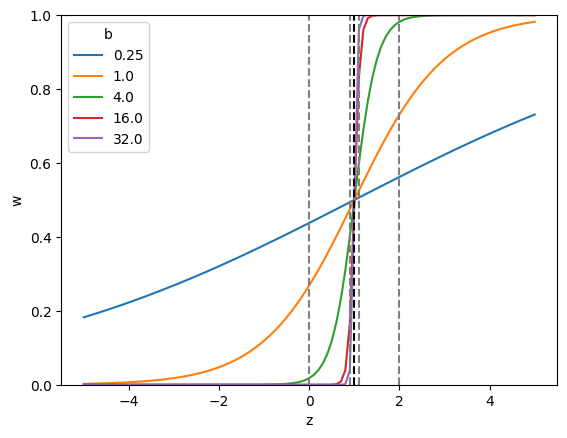

In [16]:
bs = np.array([0.25,  1, 4, 16, 32])
w_1D_s = np.array([hanoi.fit_sigmoid(a = [1], b = [b], z = z_1D) for b in bs])
[plt.plot(z_1D, w_1D_s[i,:], label = bs[i]) for i in range(len(bs))]
plt.legend(title='b')
plt.vlines(x=np.array([0, 0.9, 1,1.1, 2]), ymin = 0, ymax = 1, colors = ["gray", "gray","black", "gray", "gray"], linestyles="--")
plt.xlabel("z")
plt.ylabel("w")
plt.ylim(0, 1)
plt.savefig("L1_n1_sigmoid_fitness_funcs.pdf", bbox_inches="tight")
plt.show()

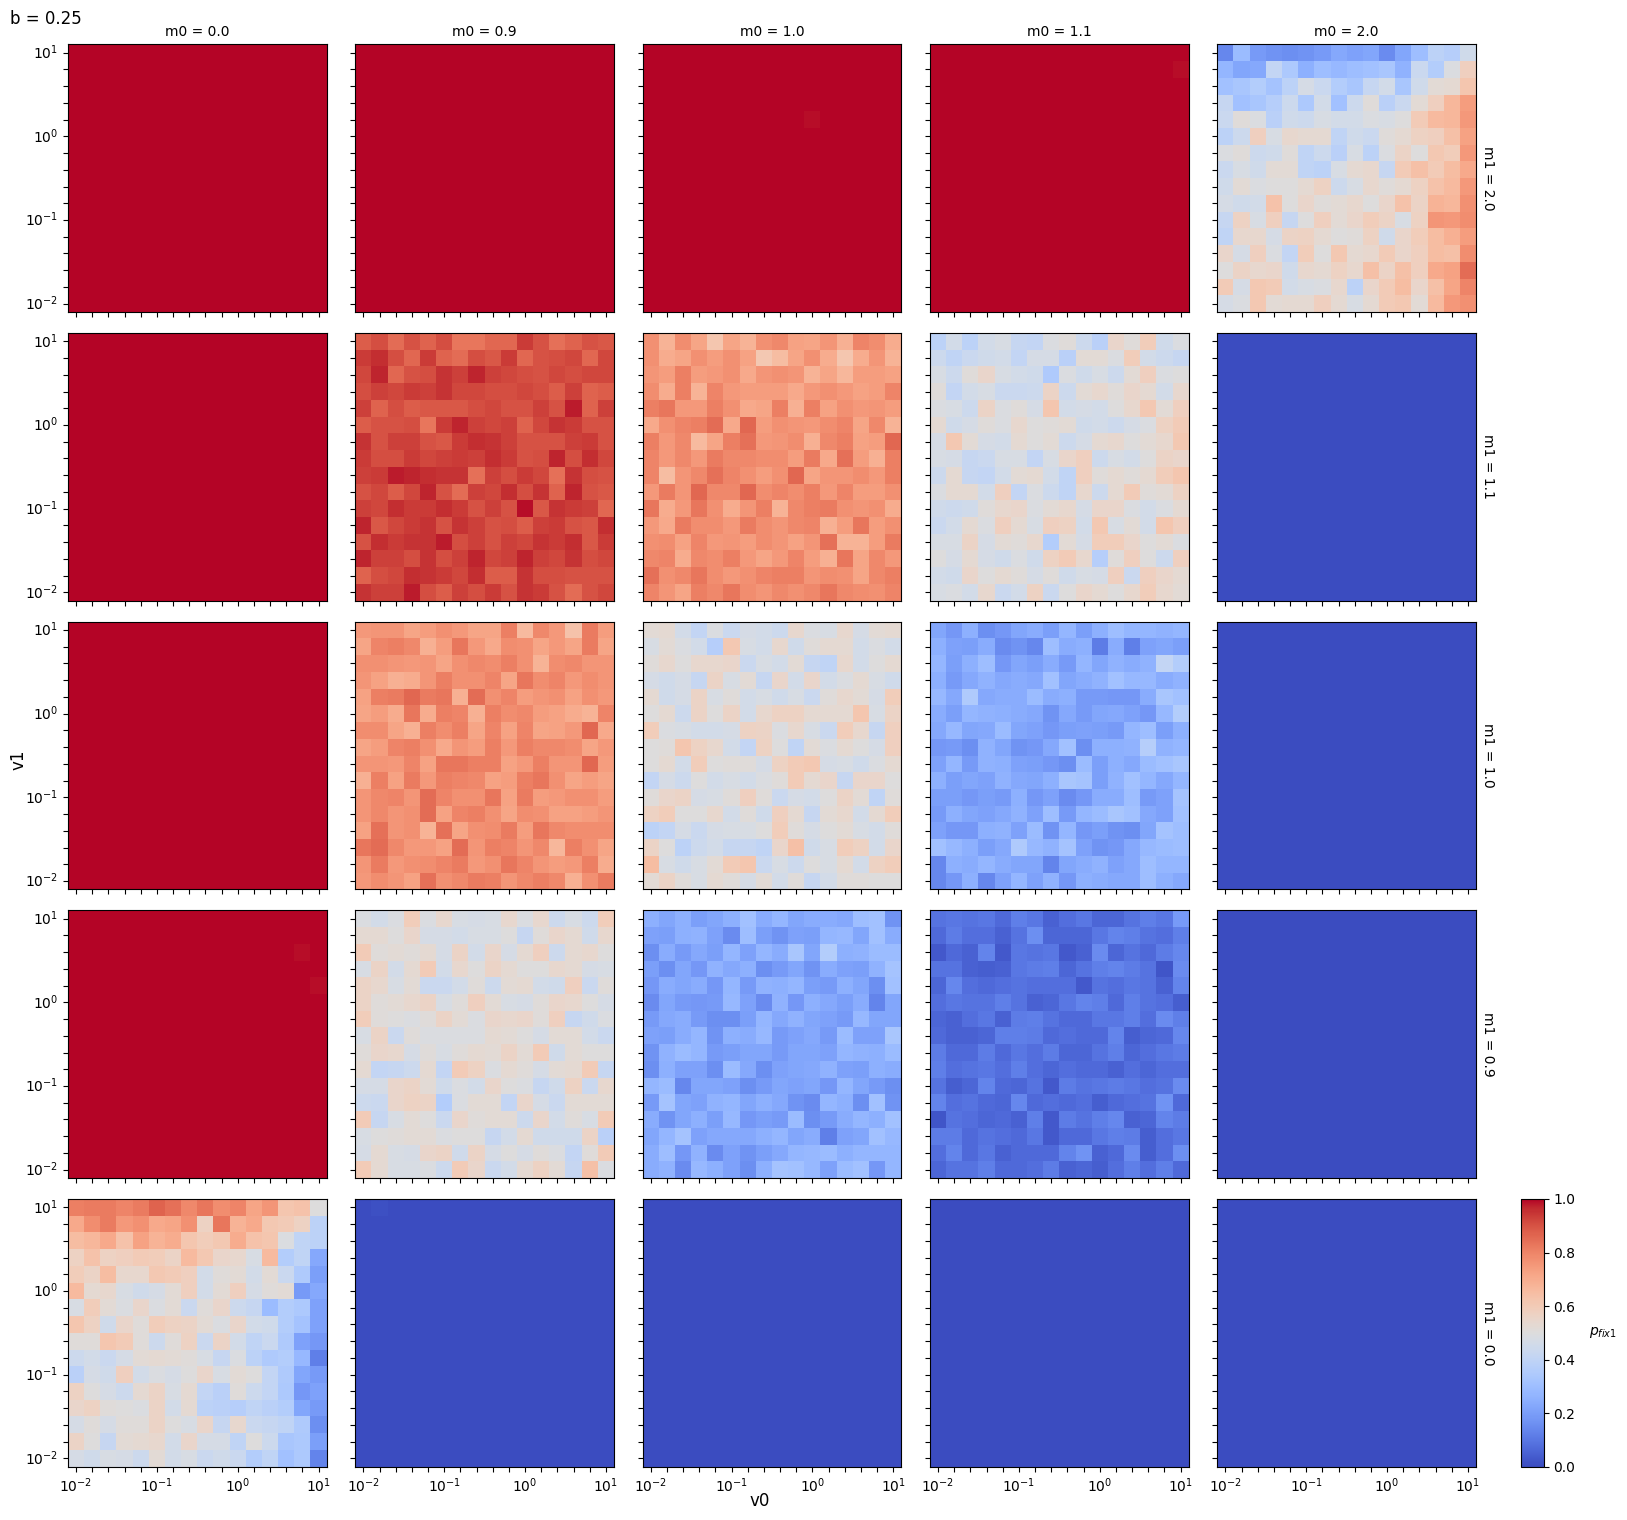

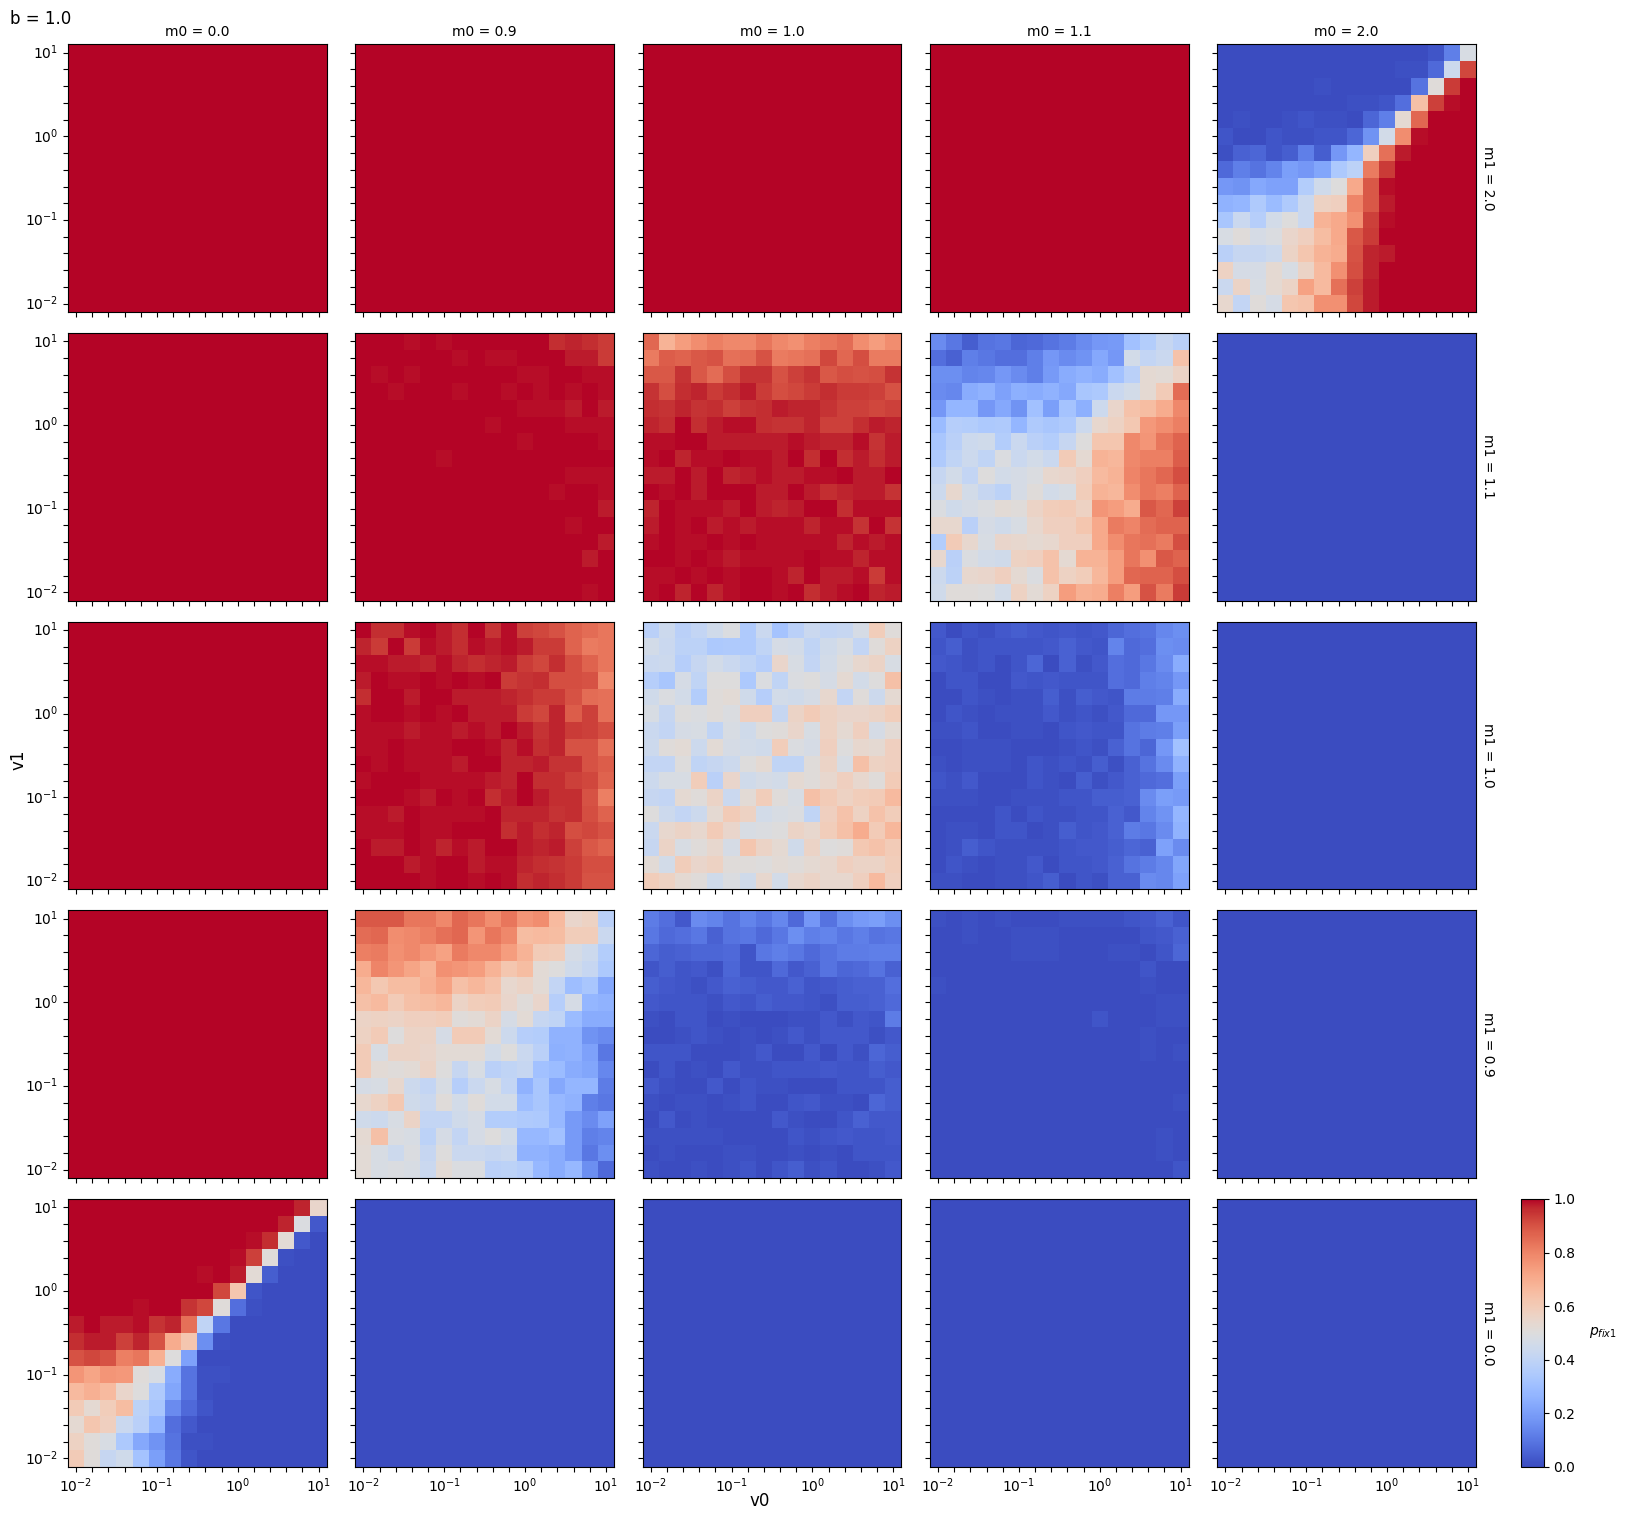

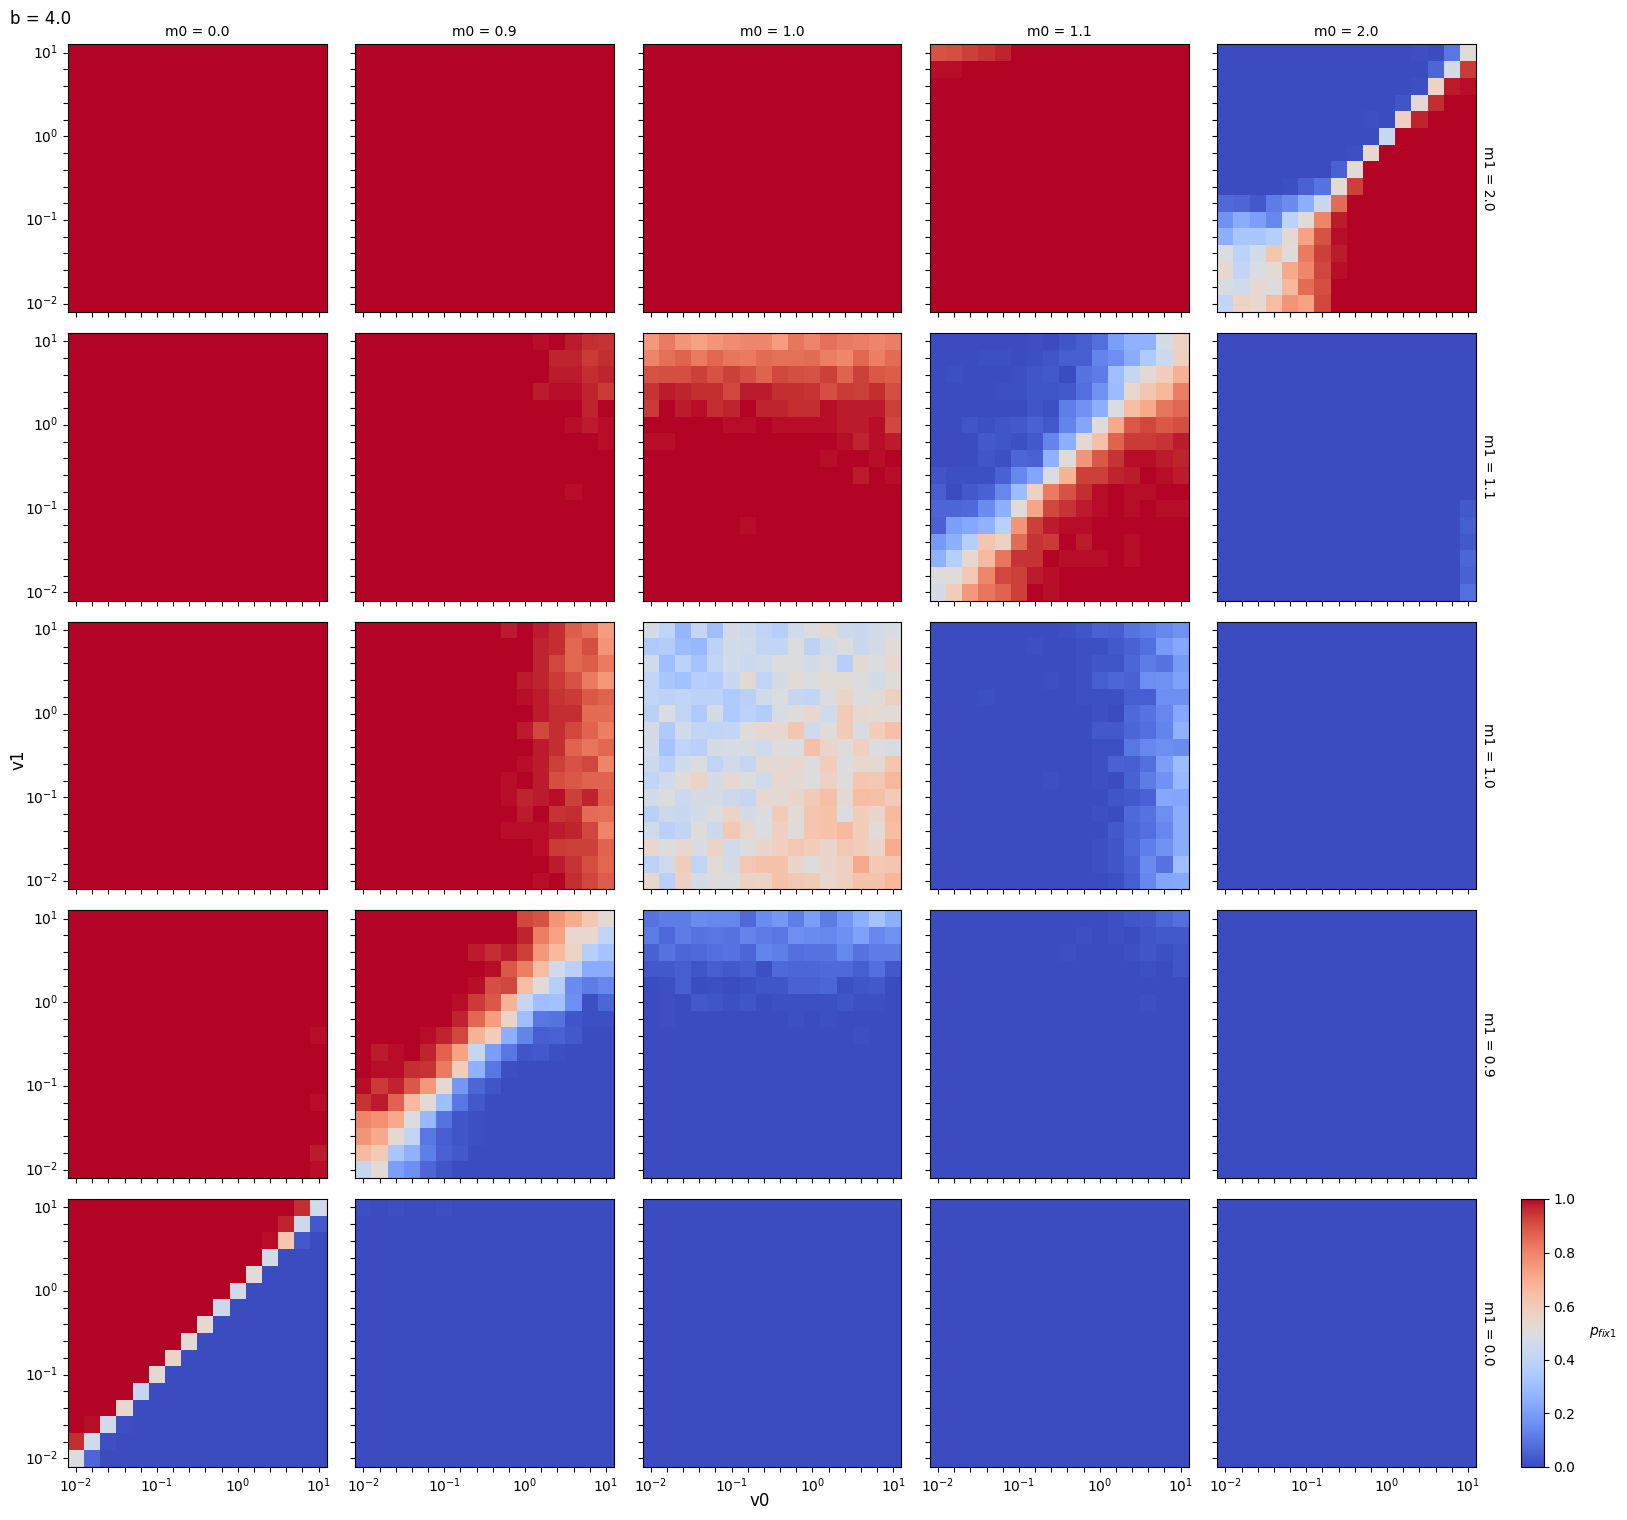

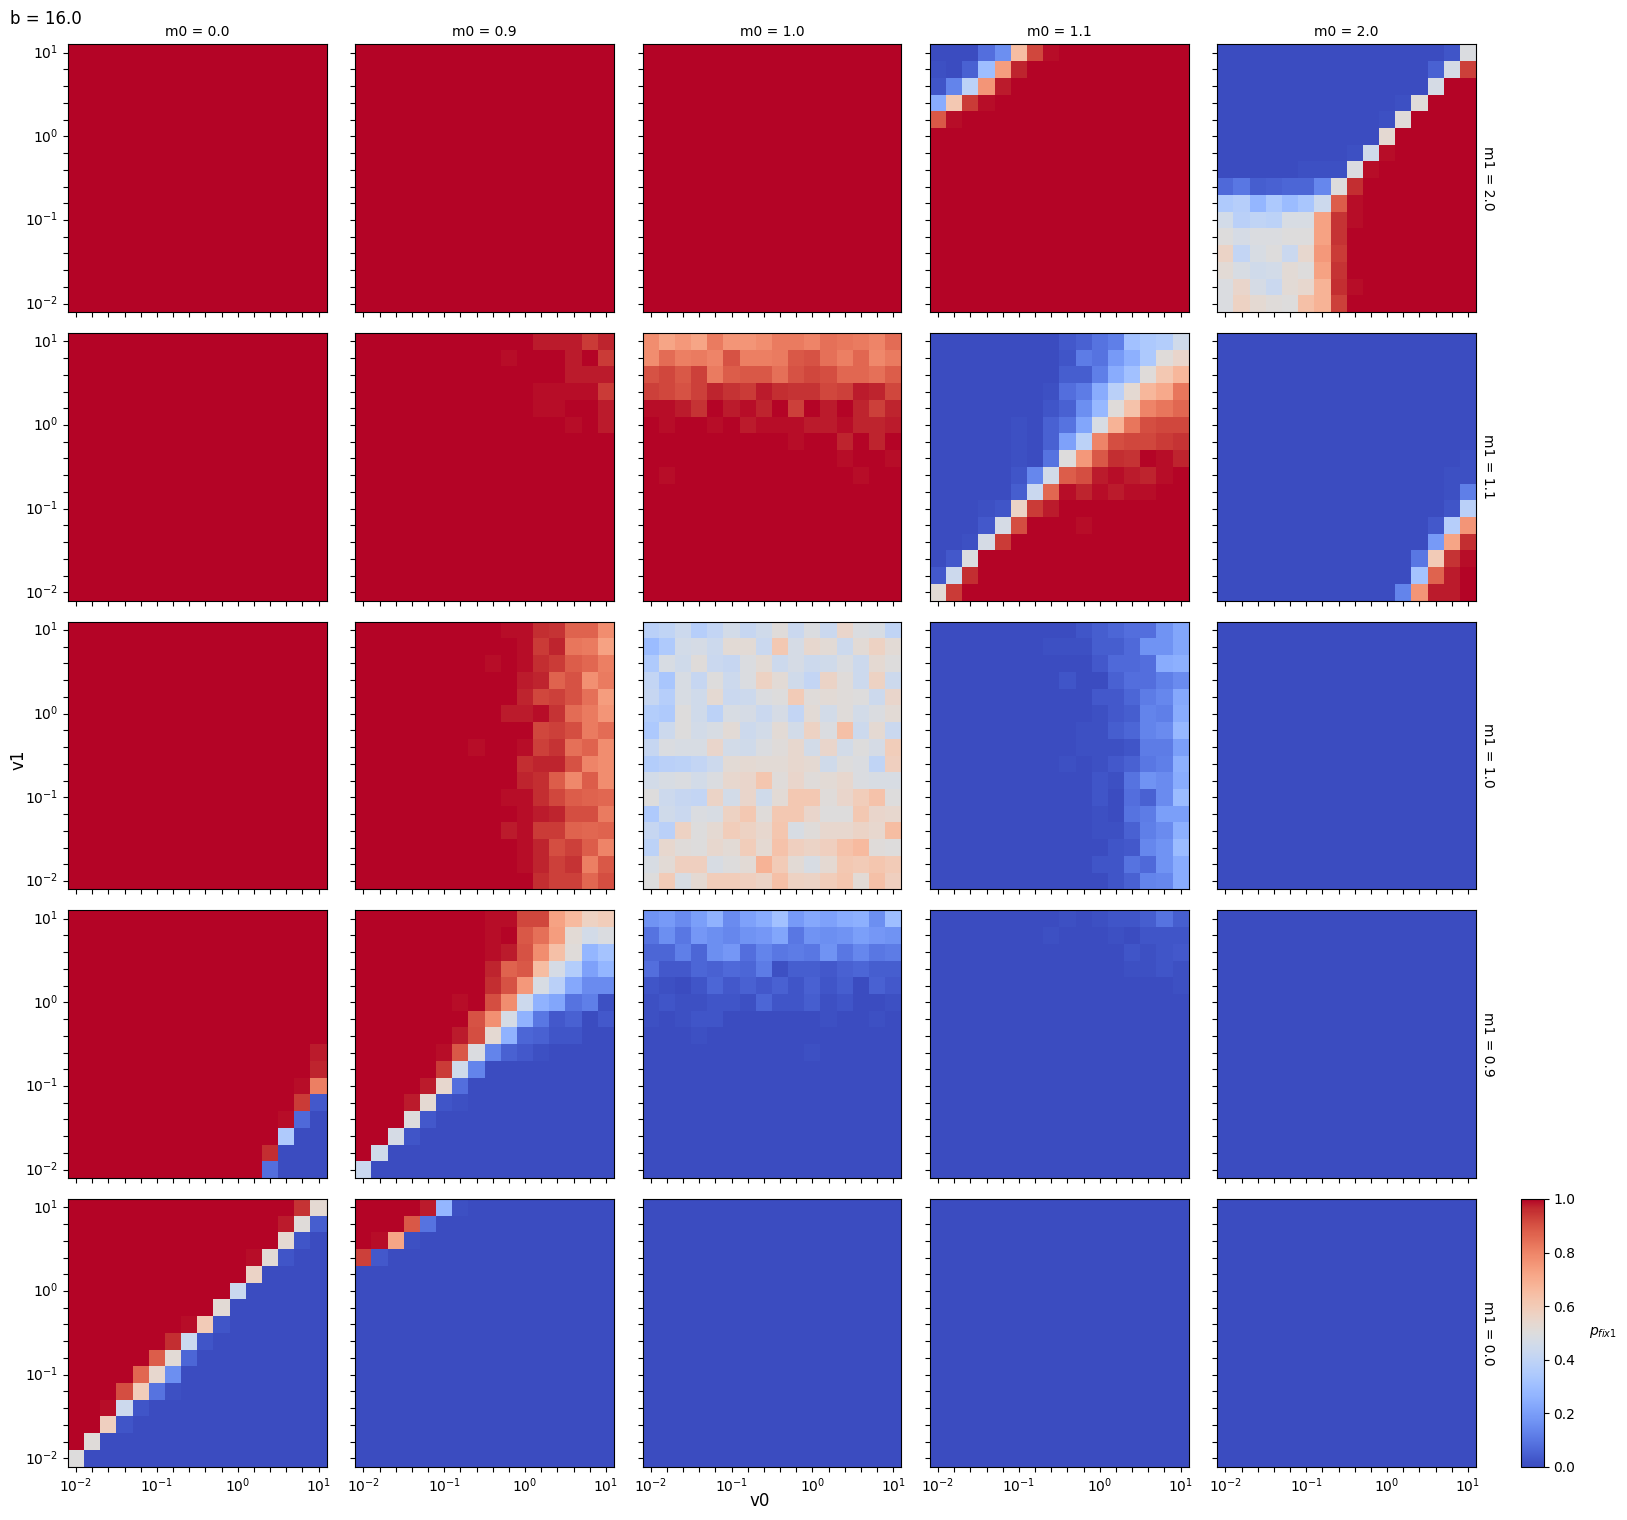

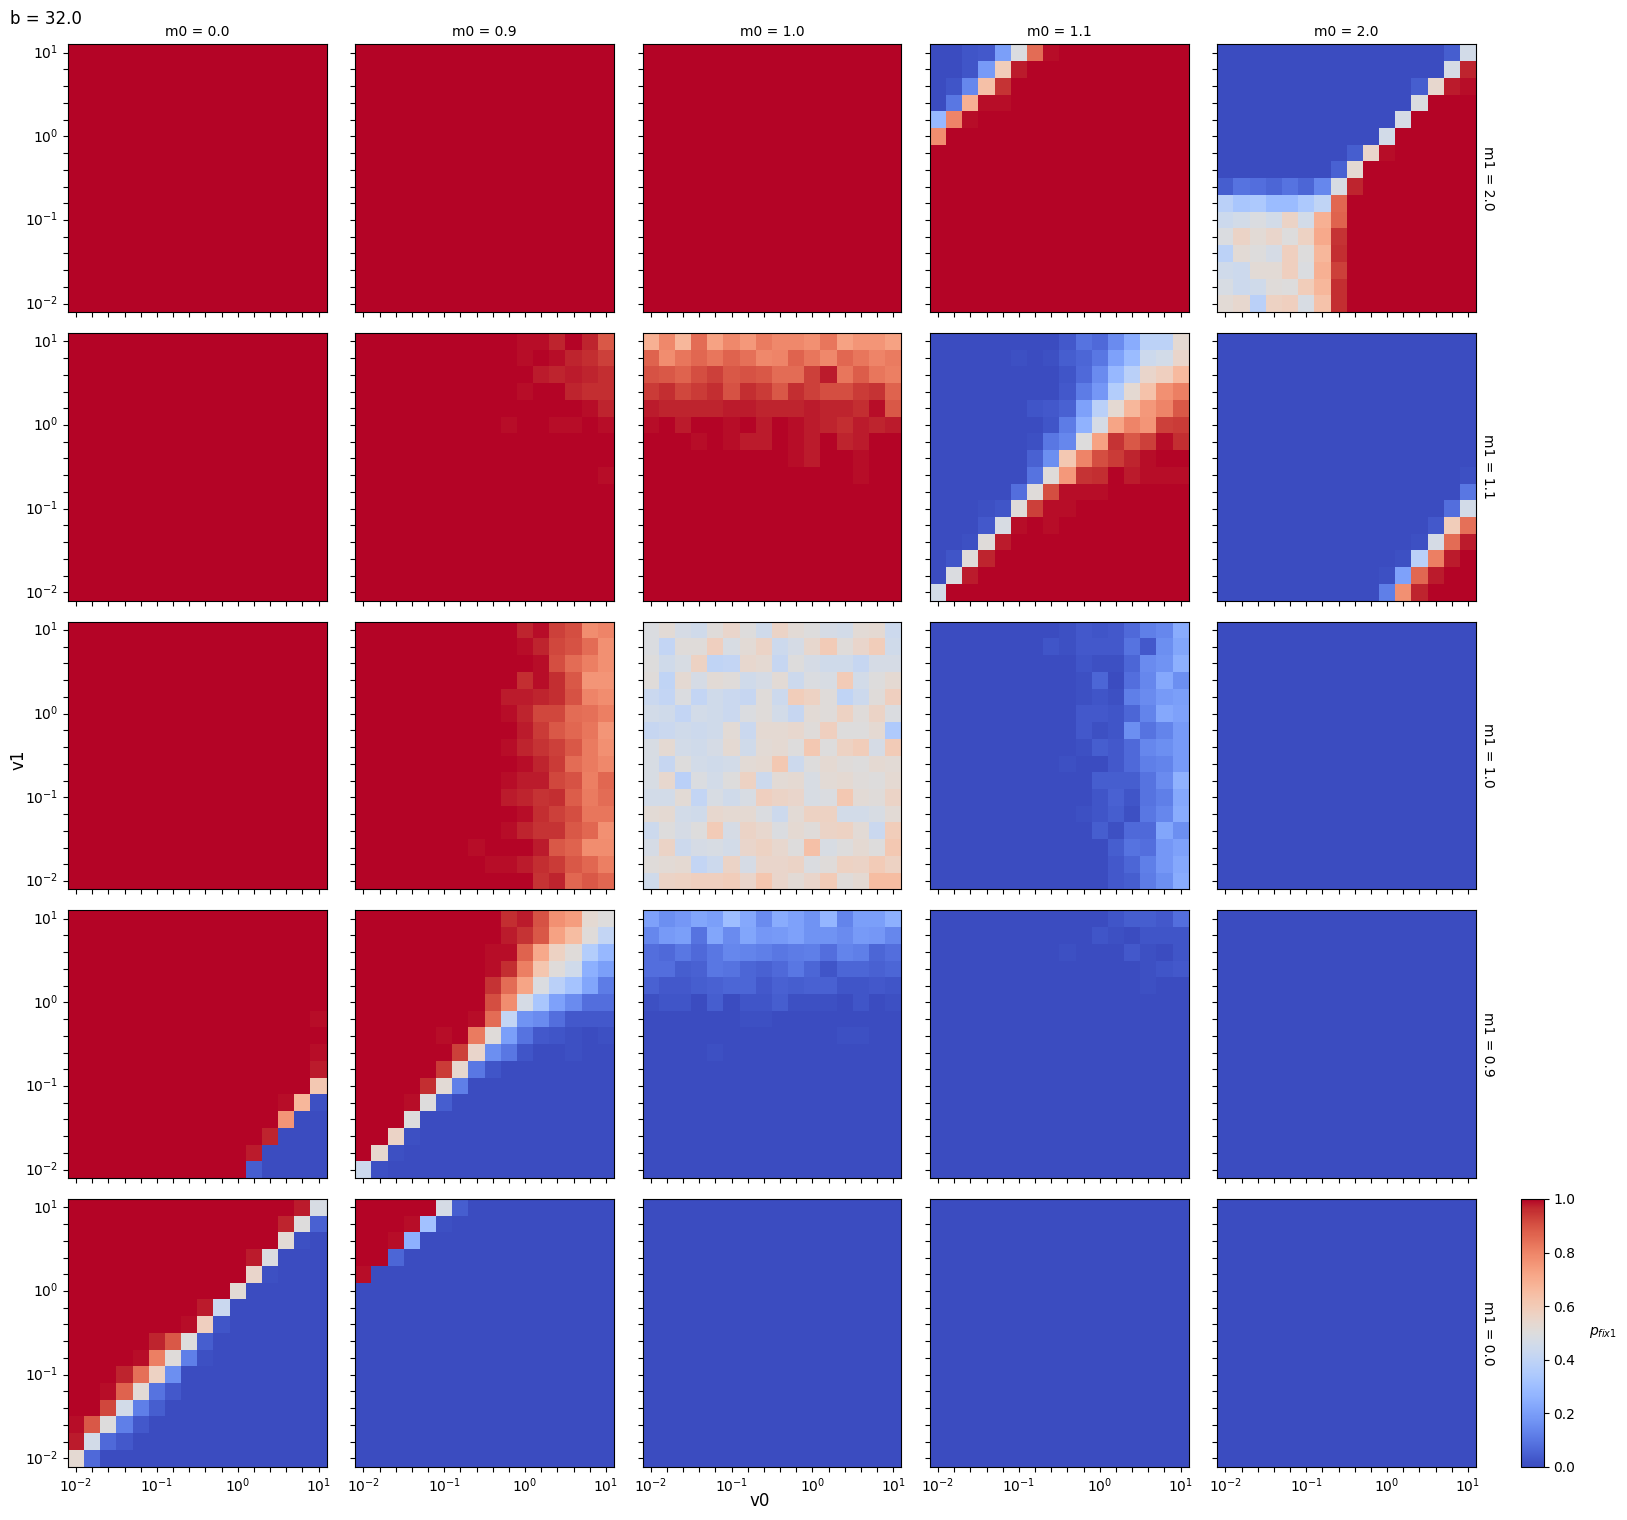

In [17]:
for b in d_smr["b"].unique():
    d_smr_sub = d_smr[d_smr["b"] == b]
    g = sns.FacetGrid(d_smr_sub, row="m1", col="m0", row_order=row_order_m, col_order=col_order_m, margin_titles=True)
    g.map_dataframe(heatmap_panel)
    g.fig.supxlabel("v0", x = 0.5, y = 0)
    g.fig.supylabel('v1', y = 0.5, x = 0)
    g.fig.suptitle(f"b = {b}", x=0, y = 1, ha='left')
    
    # Add a colorbar next to the last panel
    # Compute position of the last panel
    last_ax = g.axes[-1, -1]  # last row, last column
    pos = last_ax.get_position()  # Bbox
    
    # Create a new Axes for the colorbar: slightly thinner than a panel
    cbar_ax = g.fig.add_axes([pos.x1 + 0.03, pos.y0, 0.015, pos.height])
    # Use the same colormap and normalization
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    #g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label = "$p_{fix1}$")
    cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label("$p_{fix1}$", rotation=0, labelpad=10, va='center', ha='left')
    
    plt.show()
    g.fig.savefig(f"L1_n1_sigmoid_b_{b}_summary.svg", format="svg", bbox_inches="tight")
    g.fig.savefig(f"L1_n1_sigmoid_b_{b}_summary.pdf", format="pdf", bbox_inches="tight")

In [18]:
??hanoi.fit_gaus

Signature: hanoi.fit_gaus(sigma, z_opt, z)
Source:   
def fit_gaus(sigma, z_opt, z):
    """
    Computes fitness based on a Gaussian fitness function.

    Arguments:
        sigma: A scalar specifying SD around the peak
        z_opt: (n,) array specifying the coordinate of the peak in the n dimensional phenotypic space
        z:      (N, n) array representing n-dimensional phenotypes of N individuals.
    Returns: (N,) array representing fitness of N individuals
    """
    return np.array([np.exp(-(np.linalg.norm(z_i - z_opt))**2/(2 * sigma**2)) for z_i in z])
File:      ~/SeaDrive/My Libraries/mylib/work/projects/python/packages/hanoi/hanoi/fitness.py
Type:      function